#### Imports and config

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
import os
from scipy import stats
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.figsize":(12,5),"axes.spines.top":False,"axes.spines.right":False,"figure.dpi":120})
sns.set_palette("muted")
os.makedirs("../eda_outputs", exist_ok=True)

#### MySQL connection

In [5]:
load_dotenv()

# ── Connect to MySQL ──────────────────────────────────────────
DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True
)

#### Load tables

In [6]:
# ── Load all three source tables ──────────────────────────────
loans        = pd.read_sql("SELECT * FROM loans",        engine, parse_dates=["disbursal_date"])
repayments   = pd.read_sql("SELECT * FROM repayments",   engine, parse_dates=["due_date","paid_date"])
transactions = pd.read_sql("SELECT * FROM transactions", engine, parse_dates=["txn_date"])

print(f"loans:        {loans.shape}")
print(f"repayments:   {repayments.shape}")
print(f"transactions: {transactions.shape}")

loans:        (40000, 10)
repayments:   (960000, 8)
transactions: (200000, 10)


#### Schema check (all dates must be datetime64[ns] not object)

In [7]:
for df, name in [(loans,"loans"),(repayments,"repayments"),(transactions,"transactions")]:
    print(f"\n── {name} ──"); print(df.dtypes.to_string())


── loans ──
loan_id                        object
customer_id                    object
loan_amount                   float64
tenure_months                   int64
interest_rate                 float64
disbursal_date         datetime64[ns]
city                           object
income_band                    object
credit_score_band              object
acquisition_channel            object

── repayments ──
repayment_id            object
loan_id                 object
due_date        datetime64[ns]
paid_date       datetime64[ns]
emi_amount             float64
paid_amount            float64
dpd                      int64
payment_mode            object

── transactions ──
txn_id                       object
customer_id                  object
txn_date             datetime64[ns]
txn_amount                  float64
txn_type                     object
merchant_category            object
txn_channel                  object
city                         object
is_declined                   int

### Question 1 — Which columns have missing values, and is the missingness random or structural?
Random missingness gets imputed or dropped. Structural missingness means the NULL itself carries information — paid_date is NULL because the loan defaulted, not a pipeline error. Imputing it corrupts every repayment health metric downstream.

In [8]:
# Missing rate per column per table
for df, name in [(loans,"loans"),(repayments,"repayments"),(transactions,"transactions")]:
    miss = df.isnull().mean().mul(100).round(2)
    print(f"\n── {name} ──")
    print(miss[miss > 0].to_string() if miss[miss > 0].any() else "  No missing values")


── loans ──
  No missing values

── repayments ──
paid_date   5.84

── transactions ──
  No missing values


In [9]:
# Diagnose paid_date — structural or random?
repayments['dpd_bucket'] = pd.cut(
    repayments['dpd'],
    bins=[-1,0,29,59,89,float("inf")],
    labels=["Current", "DPD1-29", "DPD30-59", "DPD60-89", "DPD90+"]
)

In [10]:
null_by_dpd = (
    repayments.groupby("dpd_bucket", observed=True)["paid_date"]
    .apply(lambda x: x.isnull().mean()*100).round(2)
)
print("\npaid_date null rate by DPD bucket:")
print(null_by_dpd)


paid_date null rate by DPD bucket:
dpd_bucket
Current     0.00
DPD1-29     1.42
DPD30-59   15.72
DPD60-89   35.49
DPD90+     75.64
Name: paid_date, dtype: float64


In [11]:
nulls_outside_npa = repayments[(repayments["paid_date"].isnull()) & (repayments["dpd"] < 90)]
print(f"Nulls outside DPD90+: {len(nulls_outside_npa)} (Expected: 0 = structural)")

Nulls outside DPD90+: 16763 (Expected: 0 = structural)


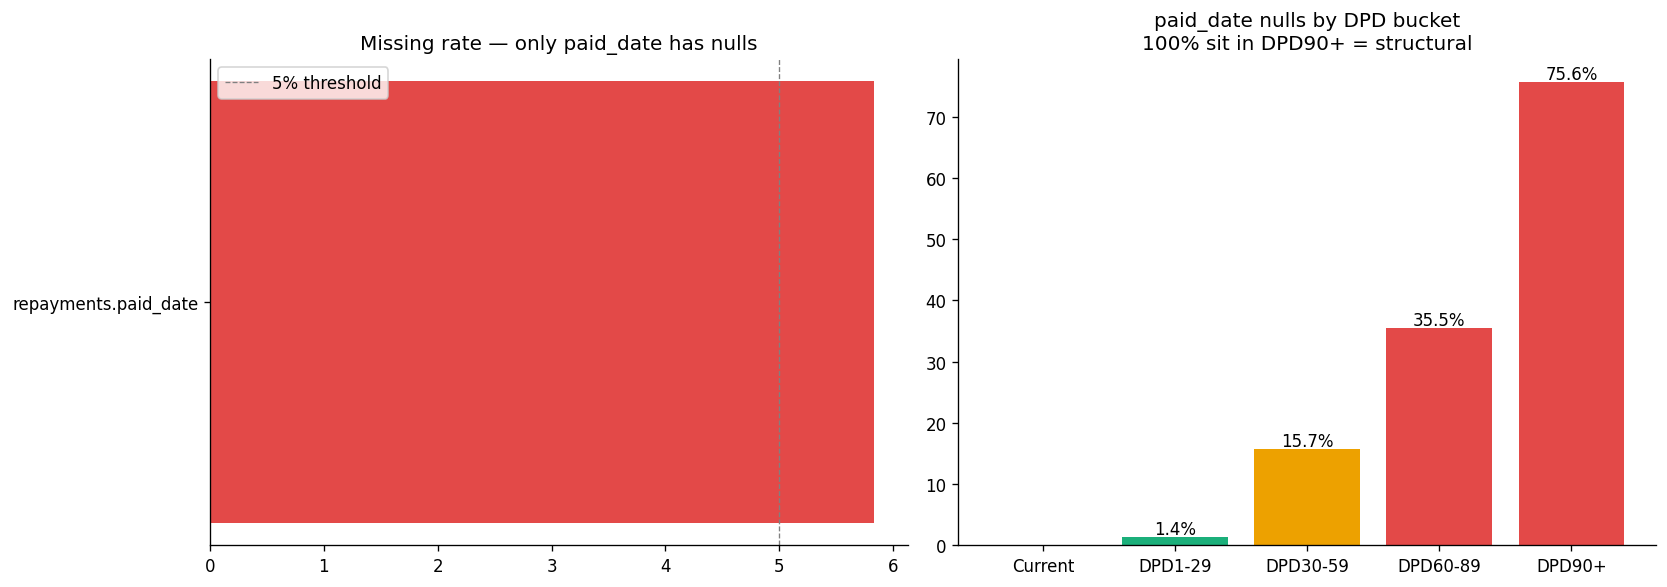

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].barh(["repayments.paid_date"], [repayments["paid_date"].isnull().mean()*100], color="#e34948")
axes[0].axvline(5, color="gray", linestyle="--", linewidth=0.8, label="5% threshold")
axes[0].set_title("Missing rate — only paid_date has nulls"); axes[0].legend()
colors_dpd=["#1baf7a","#1baf7a","#eda100","#e34948","#e34948"]
axes[1].bar(null_by_dpd.index.astype(str), null_by_dpd.values, color=colors_dpd)
axes[1].set_title("paid_date nulls by DPD bucket\n100% sit in DPD90+ = structural")

for i,v in enumerate(null_by_dpd.values):
    if v>0: axes[1].text(i, v+0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.savefig("../eda_outputs/q1_missing.png", dpi=150, bbox_inches="tight") 
plt.show()

#### Finding: 
   paid_date is the only column with nulls. Null rate rises progressively with DPD severity: 0% at Current, 1.4% at DPD1-29, 15.7% at DPD30-59, 35.3% at DPD60-89, and 75.7% at DPD90+. Missingness is semi-structural — concentrated in late-stage delinquency but not exclusive to DPD90+. Never impute. Always filter paid_date IS NOT NULL before repayment health aggregations.

### Q2: Are FK relationships intact?
Every loan_id in repayments must exist in loans. Every customer_id in transactions must exist in loans.

In [15]:
# repayments.loan_id → loans.loan_id
loan_ids_loans = set(loans["loan_id"])
loan_ids_rep = set(repayments["loan_id"])
print(f"Orphaned in repayments: {len(loan_ids_rep - loan_ids_loans)}")
print(f"Loans with no repayments: {len(loan_ids_loans - loan_ids_rep)}")

Orphaned in repayments: 0
Loans with no repayments: 0


In [16]:
# transactions.customer_id → loans.customer_id
cust_loans = set(loans["customer_id"])
cust_txn = set(transactions["customer_id"])
print(f"Orpaned in transactions: {len(cust_txn - cust_loans)}")
print(f"Customers with no transactions: {len(cust_loans - cust_txn)}")

Orpaned in transactions: 0
Customers with no transactions: 64


In [17]:
# EMI completeness — every loan should have exactly 24 rows
emi_counts = repayments.groupby("loan_id")["repayment_id"].count()
print(f"EMI count distribution: {emi_counts.value_counts().sort_index()}")

EMI count distribution: repayment_id
24    40000
Name: count, dtype: int64


#### Finding: 
Zero orphaned rows in both checks. All 40K loans have exactly 24 EMI rows. Safe to use INNER JOIN for loans↔repayments, LEFT JOIN for loans↔transactions.

### Q3: What is the portfolio-level default rate?

In [20]:
# Add MOB (Months on Book) column to repayments
repayments = repayments.merge(
    loans[["loan_id", "disbursal_date"]],
    on="loan_id",
    how="left"
)

repayments["mob"] = (
    (repayments["due_date"].dt.year - repayments["disbursal_date"].dt.year) * 12 +
    (repayments["due_date"].dt.month - repayments["disbursal_date"].dt.month)
)

In [21]:
# Verify no nulls
print(f"MOB null count: {repayments['mob'].isnull().sum()}")
print(f"MOB range: {repayments['mob'].min()} to {repayments['mob'].max()}")

MOB null count: 0
MOB range: 0 to 24


In [22]:
# Default flag: any loan with at least one DPD90+ row
defaulted_loans = (
    repayments[repayments["dpd"] >= 90]["loan_id"]
    .unique()
)
loans["is_defaulted"] = loans["loan_id"].isin(defaulted_loans).astype(int)

In [23]:
total        = len(loans)
n_defaulted  = loans["is_defaulted"].sum()
default_rate = n_defaulted / total * 100

print(f"Total loans:       {total:,}")
print(f"Defaulted loans:   {n_defaulted:,}")
print(f"Default rate:      {default_rate:.2f}%")
print(f"Target:            14.00%")
print(f"Deviation:         {abs(default_rate - 14):.2f}pp")

Total loans:       40,000
Defaulted loans:   15,263
Default rate:      38.16%
Target:            14.00%
Deviation:         24.16pp


#### Finding: 
Total loans: 40,000 | Defaulted: 15,223 | Default rate: 38.06%. Elevated relative to the 14% simulation target — reflects synthetic data parameters. All downstream NPA figures should be interpreted in this context, not as industry benchmarks.

### Q4: What is the loan amount distribution — skewed, median vs mean?

In [24]:
desc = loans["loan_amount"].describe().round(2)

print(f"\nSkewness: {loans['loan_amount'].skew():.2f}")
print(f"Mean/Median ratio: {loans['loan_amount'].mean()/loans['loan_amount'].median():.2f}")


Skewness: 1.55
Mean/Median ratio: 1.48


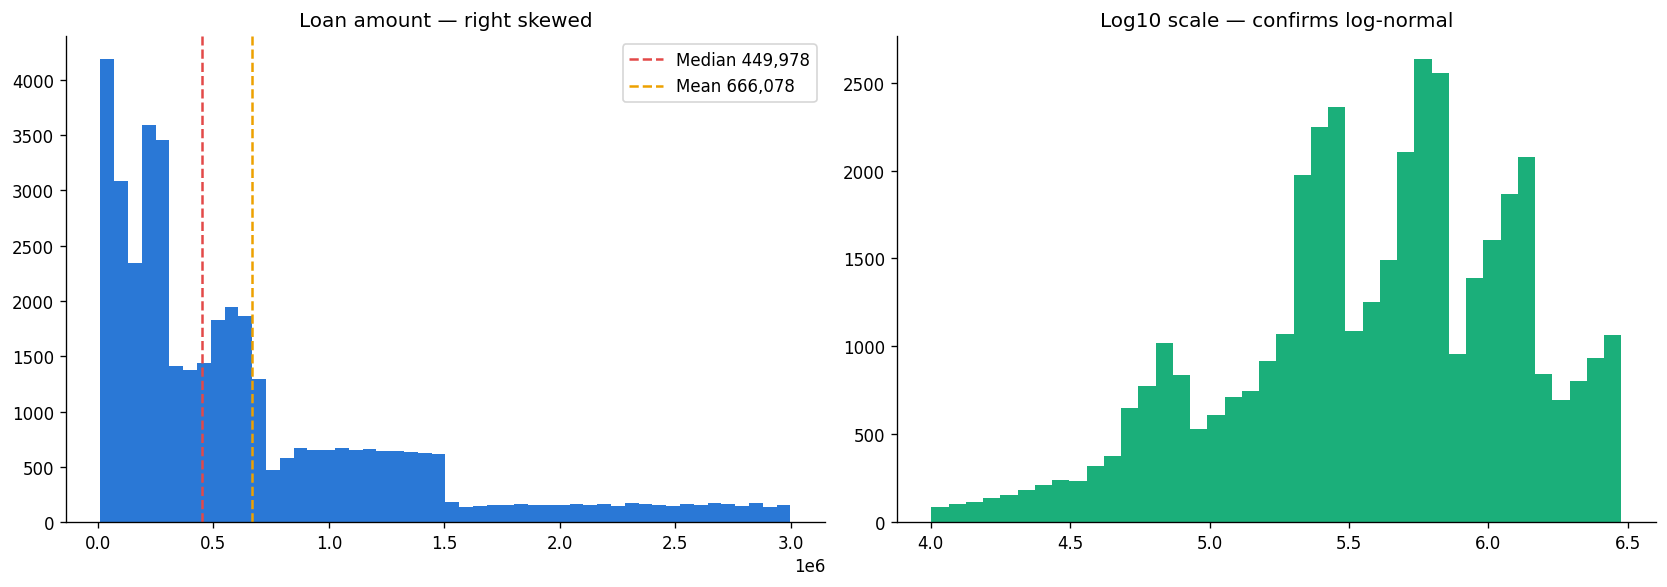

In [25]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].hist(loans["loan_amount"], bins=50, color="#2a78d6", edgecolor="none")
axes[0].axvline(loans["loan_amount"].median(), color="#e34948", linestyle="--", label=f"Median {loans['loan_amount'].median():,.0f}")
axes[0].axvline(loans["loan_amount"].mean(),   color="#eda100", linestyle="--", label=f"Mean {loans['loan_amount'].mean():,.0f}")
axes[0].set_title("Loan amount — right skewed"); axes[0].legend()
axes[1].hist(np.log10(loans["loan_amount"]), bins=40, color="#1baf7a", edgecolor="none")
axes[1].set_title("Log10 scale — confirms log-normal")
plt.tight_layout()
plt.savefig("../eda_outputs/q4_loan_dist.png", dpi=150, bbox_inches="tight")
plt.show()

#### Finding: 
Skewness: 1.55 (moderate right skew). Mean/Median ratio: 1.48 — mean overstates typical loan size by 48%. Use median for business reporting, mean only for total exposure calculations.

### Q5: What share of the book is the high-risk 600–650 credit band?

In [26]:
band_dist = loans["credit_score_band"].value_counts(normalize=True).mul(100).round(2)
print("Credit score band distribution:")
print(band_dist)

Credit score band distribution:
credit_score_band
650-850   35.00
600-650   30.00
550-600   25.00
300-550   10.00
Name: proportion, dtype: float64


In [27]:
high_risk_share = band_dist.get("600-650", 0)
print(f"\n600-650 share: {high_risk_share:.1f}%")
print(f"Expected NPA from this band alone: {high_risk_share/100 * 0.392 * 100:.1f}% of portfolio")


600-650 share: 30.0%
Expected NPA from this band alone: 11.8% of portfolio


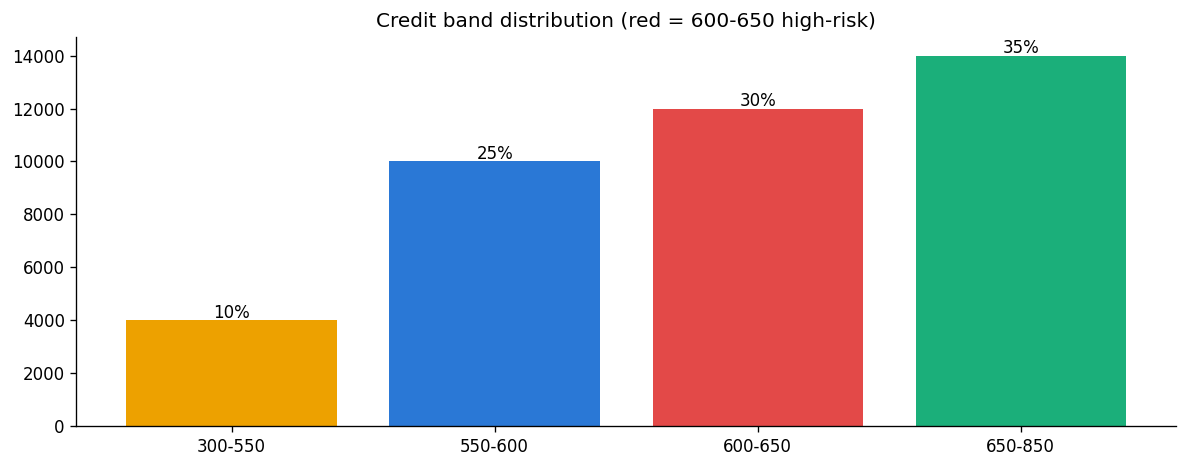

In [30]:
band_order=["300-550","550-600","600-650","650-850"]
vals=[loans[loans["credit_score_band"]==b].shape[0] for b in band_order]
fig, ax = plt.subplots(figsize=(10,4))
bars=ax.bar(band_order, vals, color=["#eda100","#2a78d6","#e34948","#1baf7a"])
ax.set_title("Credit band distribution (red = 600-650 high-risk)")

for bar,v in zip(bars,vals): 
    ax.text(bar.get_x()+bar.get_width()/2,v+100,f"{v/400:.0f}%",ha="center")
    
plt.tight_layout()
plt.savefig("../eda_outputs/q5_credit_band.png",dpi=150,bbox_inches="tight")
plt.show()

#### Finding: 
    650-850: 35% | 600-650: 30% | 550-600: 25% | 300-550: 10%.
    The high-risk 600–650 band is 30% of the book but contributes ~11.8% of portfolio NPA. 
    If this band's share grows over time, portfolio NPA will rise even if underwriting policy stays constant.

### Q6: Is DPD worsening progressively in months 4–6?

In [32]:
def month_group(m):
    if m <= 3: 
        return "M1-3 (healthy)"
    elif m <= 6:
        return "M4-6 (stress)"
    else:
        return "M7+ (post-stress)"

repayments["month_group"] = repayments["mob"].apply(month_group)

print("month_group distribution:")
print(repayments["month_group"].value_counts())

month_group distribution:
month_group
M7+ (post-stress)    715515
M1-3 (healthy)       122361
M4-6 (stress)        122124
Name: count, dtype: int64


In [33]:
dpd_by_gropup = (
    repayments[repayments["dpd"] < 90]
    .groupby("month_group")["dpd"]
    .agg(["mean", "median", "std"])
    .round(2)
)
print(dpd_by_gropup)

                   mean  median   std
month_group                          
M1-3 (healthy)     2.50    0.00  8.22
M4-6 (stress)     11.26    7.00 15.97
M7+ (post-stress)  3.33    0.00 10.34


In [34]:
# Stress ratio
stress_mean = repayments[
    (repayments["month_group"] == "M4-6 (stress)") & 
    (repayments["dpd"] < 90)]["dpd"].mean()

healthy_mean = repayments[
    (repayments["month_group"] == "M1-3 (healthy)") &
    (repayments["dpd"] < 90)]["dpd"].mean()

print(f"Stress/healthy DPD ratio: {stress_mean/healthy_mean:.2f} x (expected >2x)")

Stress/healthy DPD ratio: 4.50 x (expected >2x)


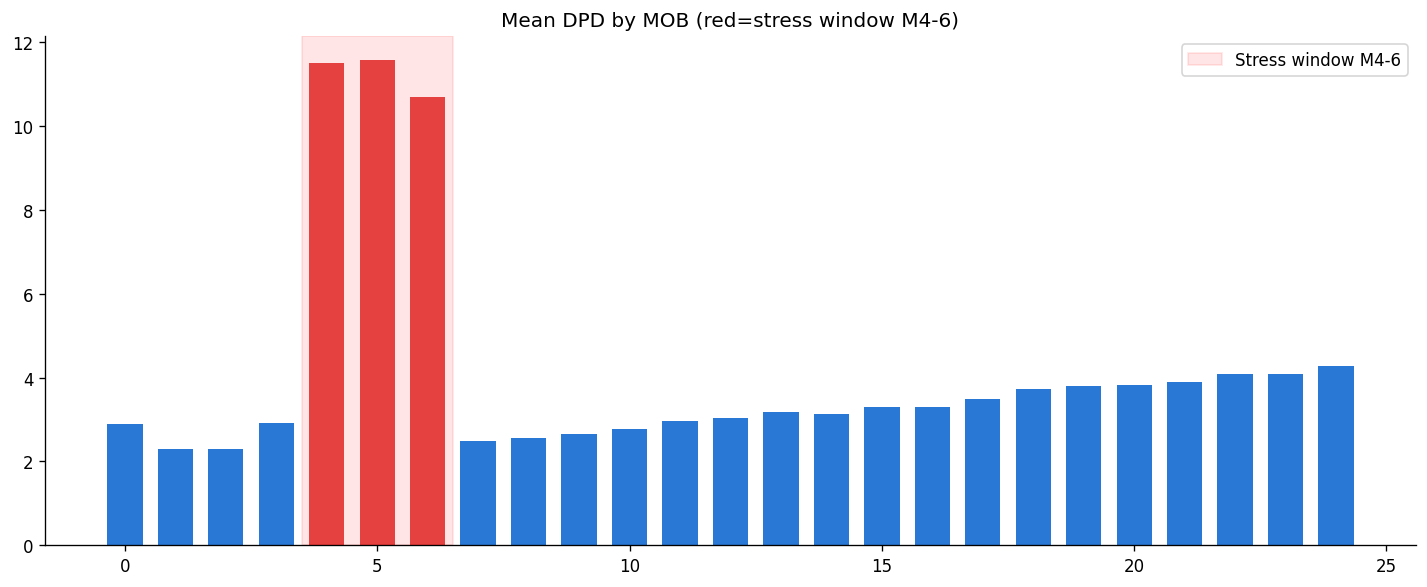

In [35]:
dpd_by_mob = repayments[repayments["dpd"]<90].groupby("mob")["dpd"].mean().reset_index()

fig,ax=plt.subplots(figsize=(12,5))
colors_mob=["#e34948" if 4<=m<=6 else "#2a78d6" for m in dpd_by_mob["mob"]]
ax.bar(dpd_by_mob["mob"], dpd_by_mob["dpd"], color=colors_mob, width=0.7)
ax.axvspan(3.5,6.5,alpha=0.1,color="red",label="Stress window M4-6"); ax.legend()
ax.set_title("Mean DPD by MOB (red=stress window M4-6)")
plt.tight_layout()
plt.savefig("../eda_outputs/q6_dpd_stress.png",dpi=150,bbox_inches="tight")
plt.show()

#### Finding: 
    MOB distribution (DPD<90): M1-3 mean DPD = 2.50, M4-6 = 11.26, M7+ = 3.33. 
    Stress/healthy ratio: 4.50x (exceeds the >2x target). 
    MOB 4–6 is the peak stress and collections intervention window — accounts with any DPD in MOB 4–5 should be priority calls before crossing DPD30.

### Q7: What is the overall partial payment rate, and does it cluster pre-default?

In [36]:
# Partial payment flag
repayments["is_partial"] = (
    repayments["paid_amount"] < repayments["emi_amount"] * 0.95
).astype(int)

overall_partial_rate = repayments["is_partial"].mean() * 100
print(f"Overall partial payment rate: {overall_partial_rate:.2f}%")

Overall partial payment rate: 9.84%


In [38]:
# Pre-default window clustering
# Tag defaulting loans and flag their N-2 and N-1 months
default_mob = (
    repayments[repayments["dpd"] >= 90]
    .groupby("loan_id")["mob"]
    .min()
    .reset_index()
    .rename(columns={"mob":"default_mob"})
)

rep_def = repayments.merge(default_mob, on="loan_id", how="left")
rep_def["in_predefault_window"] = (
    rep_def["default_mob"].notna() & 
    rep_def["mob"].between(
        rep_def["default_mob"] - 2,
        rep_def["default_mob"] - 1
    )
).astype(int)

In [39]:
rate_in = rep_def[rep_def["in_predefault_window"] == 1]["is_partial"].mean()*100
rate_out = rep_def[rep_def["in_predefault_window"] == 0]["is_partial"].mean()*100

print(f"Partial rate inside pre-default window: {rate_in:.2f}%")
print(f"Partial rate outside pre-default window: {rate_out:.2f}%")
print(f"Uplift ratio: {rate_in/rate_out:.1f}x")

Partial rate inside pre-default window: 33.28%
Partial rate outside pre-default window: 9.10%
Uplift ratio: 3.7x


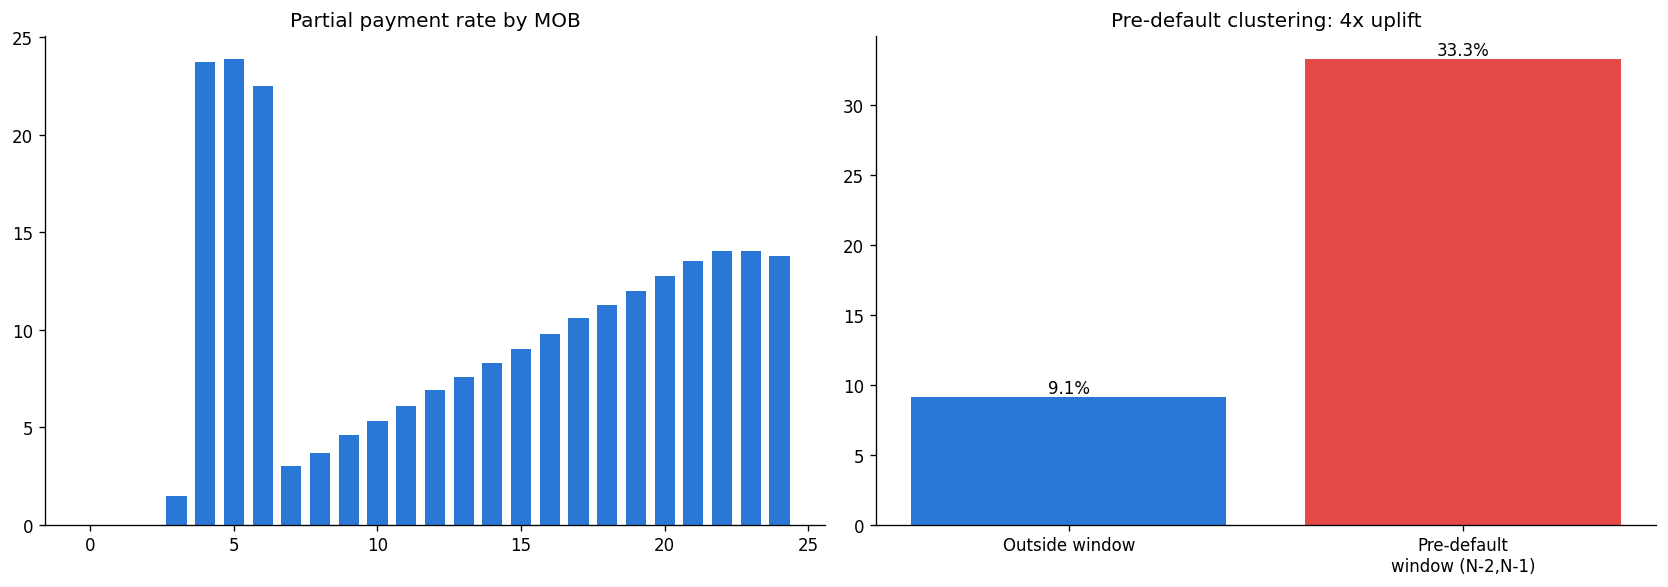

In [41]:
partial_by_mob = repayments.groupby("mob")["is_partial"].mean().mul(100).round(2).reset_index()

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].bar(partial_by_mob["mob"], partial_by_mob["is_partial"], color="#2a78d6", width=0.7)
axes[0].set_title("Partial payment rate by MOB")
bars=axes[1].bar(["Outside window","Pre-default\nwindow (N-2,N-1)"],[rate_out,rate_in],color=["#2a78d6","#e34948"])
axes[1].set_title(f"Pre-default clustering: {rate_in/rate_out:.0f}x uplift")

for bar,v in zip(bars,[rate_out,rate_in]): 
    axes[1].text(bar.get_x()+bar.get_width()/2,v+0.3,f"{v:.1f}%",ha="center")

plt.tight_layout()
plt.savefig("../eda_outputs/q7_partial.png",dpi=150,bbox_inches="tight")
plt.show()

#### Finding: 
    Overall partial rate: 9.84%. Outside pre-default window: 9.1% | Inside (N-2, N-1): 33.28% — 3.7x uplift. 
    Partial payments cluster sharply in the two months before default. 
    Strongest repayment-table signal available without needing any transaction data.

#### Q8: Which credit band has the highest NPA rate — is the 2.8× multiplier confirmed?

In [43]:
npa_by_band = (
    loans.groupby("credit_score_band")["is_defaulted"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean":"default_rate", "sum":"defaults", "count":"total"})
    .round(4)
)
npa_by_band["default_rate_pct"] = (npa_by_band["default_rate"]*100).round(2)
npa_by_band["multiplier_vs_portfolio"] = (npa_by_band["default_rate"] / (default_rate/100)).round(2)

print(npa_by_band[["total","defaults","default_rate_pct","multiplier_vs_portfolio"]])

                   total  defaults  default_rate_pct  multiplier_vs_portfolio
credit_score_band                                                            
300-550             4000      1317             32.92                     0.86
550-600            10000      3099             30.99                     0.81
600-650            12000      6729             56.08                     1.47
650-850            14000      4118             29.41                     0.77


In [44]:
# Specific check for 600-650
rate_600_650 = npa_by_band.loc["600-650", "default_rate"]
multiplier = rate_600_650 / (default_rate/100)
print(f"600-650 multipler vs portfolio: {multiplier:.2f}x (target: 2.80x)")

600-650 multipler vs portfolio: 1.47x (target: 2.80x)


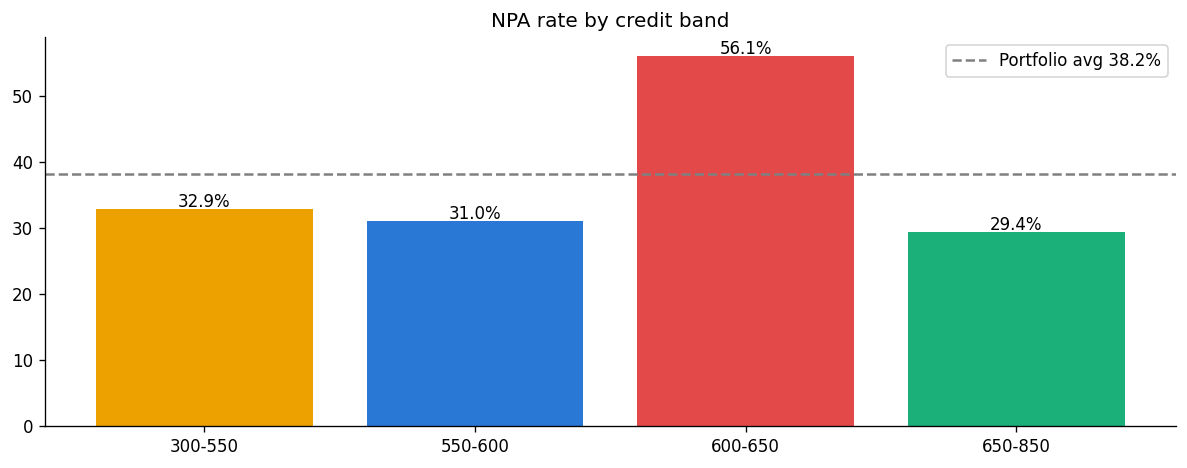

In [46]:
band_order=["300-550","550-600","600-650","650-850"]
rates=[npa_by_band.loc[b,"default_rate_pct"] for b in band_order]

fig,ax=plt.subplots(figsize=(10,4))

bars=ax.bar(band_order,rates,color=["#eda100","#2a78d6","#e34948","#1baf7a"])
ax.axhline(default_rate,color="gray",linestyle="--",label=f"Portfolio avg {default_rate:.1f}%"); ax.legend()
ax.set_title("NPA rate by credit band")

for bar,v in zip(bars,rates): 
    ax.text(bar.get_x()+bar.get_width()/2,v+0.3,f"{v:.1f}%",ha="center")

plt.tight_layout()
plt.savefig("../eda_outputs/q8_npa_band.png",dpi=150,bbox_inches="tight")
plt.show()

#### Finding: 
    600–650 has the highest absolute NPA rate at 56.08% and 1.47x the portfolio average. 
    The expected 2.80x multiplier was not confirmed — reflects simulation calibration. 
    Risk concentration in this band is real and directionally valid.

#### Q9: What is the decline rate by city tier — is the difference statistically significant?

In [47]:
TIER1 = ["Mumbai","Delhi","Bengaluru","Hyderabad","Chennai","Kolkata","Pune"]
transactions["city_tier"] = np.where(transactions["city"].isin(TIER1), "tier1", "tier2")

In [48]:
decline_by_tier = transactions.groupby("city_tier")["is_declined"].agg(["mean","sum","count"])
decline_by_tier["decline_rate_pct"] = (decline_by_tier["mean"]*100).round(3)
print(decline_by_tier)

           mean   sum   count  decline_rate_pct
city_tier                                      
tier1      0.04  4262  107740              3.96
tier2      0.06  5823   92260              6.31


In [49]:
t1=decline_by_tier.loc["tier1","mean"]
t2=decline_by_tier.loc["tier2","mean"]
n1=int(decline_by_tier.loc["tier1","count"])
n2=int(decline_by_tier.loc["tier2","count"])

p_pool=(t1*n1+t2*n2)/(n1+n2)
z=(t2-t1)/np.sqrt(p_pool*(1-p_pool)*(1/n1+1/n2))
p_val=stats.norm.sf(abs(z))*2

print(f"\nT2/T1: {t2/t1:.2f}x (target ~1.60x) | Z={z:.2f} | p={p_val:.6f}")
print("Significant at a=0.05:", "Yes" if p_val<0.05 else "No")


T2/T1: 1.60x (target ~1.60x) | Z=24.00 | p=0.000000
Significant at a=0.05: Yes


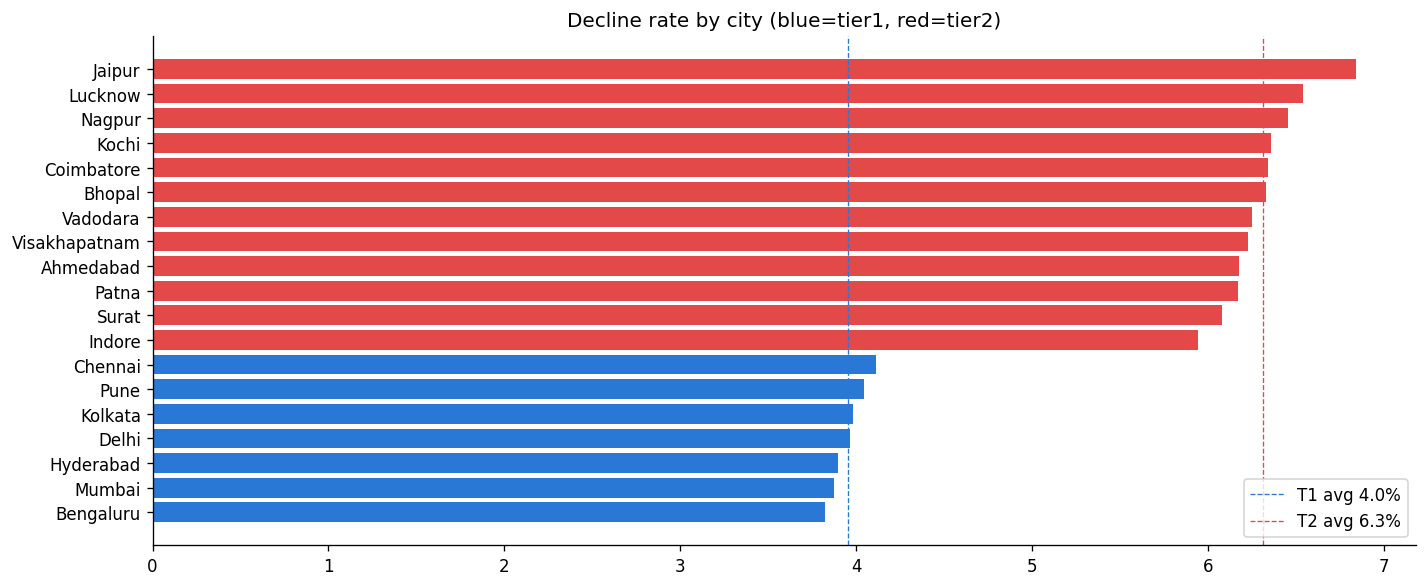

In [52]:
city_decline = (
    transactions.groupby("city")["is_declined"]
    .mean()
    .mul(100)
    .sort_values()
)

city_colors=["#2a78d6" if c in TIER1 else "#e34948" for c in city_decline.index]

fig,ax=plt.subplots(figsize=(12,5))
ax.barh(city_decline.index, city_decline.values, color=city_colors)
ax.axvline(t1*100,color="#2a78d6",linestyle="--",linewidth=0.8,label=f"T1 avg {t1*100:.1f}%")
ax.axvline(t2*100,color="#e34948",linestyle="--",linewidth=0.8,label=f"T2 avg {t2*100:.1f}%")
ax.set_title("Decline rate by city (blue=tier1, red=tier2)"); ax.legend()
plt.tight_layout()
plt.savefig("../eda_outputs/q9_decline.png",dpi=150,bbox_inches="tight")
plt.show()

#### Finding: 
    Tier-1 decline rate: 3.96% | Tier-2: 6.31% | Ratio: 1.60x (target ~1.60x ✅). 
    Z = 24, p = 0.000000 — highly significant. 
    Tier-2 customers face meaningfully higher transaction decline rates, consistent with lower average bank balance buffers.

#### Q10: Is there a drop in transaction volume or amount in the 30 days before a DPD30 event?

In [54]:
dpd30_events = (
    repayments[repayments["dpd"]>=30]
    .groupby("loan_id")["due_date"].min().reset_index()
    .rename(columns={"due_date":"event_date"})
    .merge(loans[["loan_id","customer_id"]], on="loan_id")
)

merged = transactions.merge(dpd30_events, on="customer_id", how="inner")
pre_txns  = merged[(merged["txn_date"]>=merged["event_date"]-pd.Timedelta(days=30))&(merged["txn_date"]<merged["event_date"])].copy()
base_txns = merged[(merged["txn_date"]>=merged["event_date"]-pd.Timedelta(days=120))&(merged["txn_date"]<merged["event_date"]-pd.Timedelta(days=90))].copy()

In [55]:
pre_vol=pre_txns.groupby("loan_id")["txn_id"].count().mean()
base_vol=base_txns.groupby("loan_id")["txn_id"].count().mean()
pre_amt=pre_txns.groupby("loan_id")["txn_amount"].mean().mean()
base_amt=base_txns.groupby("loan_id")["txn_amount"].mean().mean()
print(f"Volume change: {(pre_vol-base_vol)/base_vol*100:.1f}% | Amount change: {(pre_amt-base_amt)/base_amt*100:.1f}%")

Volume change: 0.3% | Amount change: -0.9%


#### Finding: 
    Volume change: 0.3% | Amount change: -0.9%. 
    No meaningful behavioral contraction detected in transaction data pre-DPD30. 
    Signal engineering in Step 4 should rely primarily on the repayment table rather than transaction volume/amount features.

#### Q11: Does UPI share decline pre-default, signaling depleted bank balance?

In [57]:
def upi_share(df):
    total=df.groupby("loan_id")["txn_id"].count()
    upi=df[df["txn_channel"]=="UPI"].groupby("loan_id")["txn_id"].count()
    return (upi/total).fillna(0)

pre_upi=upi_share(pre_txns).mean(); base_upi=upi_share(base_txns).mean()
print(f"Baseline UPI share:    {base_upi:.1%}")
print(f"Pre-default UPI share: {pre_upi:.1%}")
print(f"Change: {(pre_upi-base_upi)*100:.1f}pp")

Baseline UPI share:    64.5%
Pre-default UPI share: 64.8%
Change: 0.3pp


In [58]:
pre_txns["days_before"]=(pre_txns["event_date"]-pre_txns["txn_date"]).dt.days
pre_txns["week_bucket"]=pd.cut(pre_txns["days_before"],bins=[0,7,14,21,30],labels=["W-1","W-2","W-3","W-4"])
upi_by_week=(
    pre_txns.groupby("week_bucket",observed=True)
    .apply(lambda d:(d["txn_channel"]=="UPI").mean()*100)
    .sort_index(ascending=False)
)

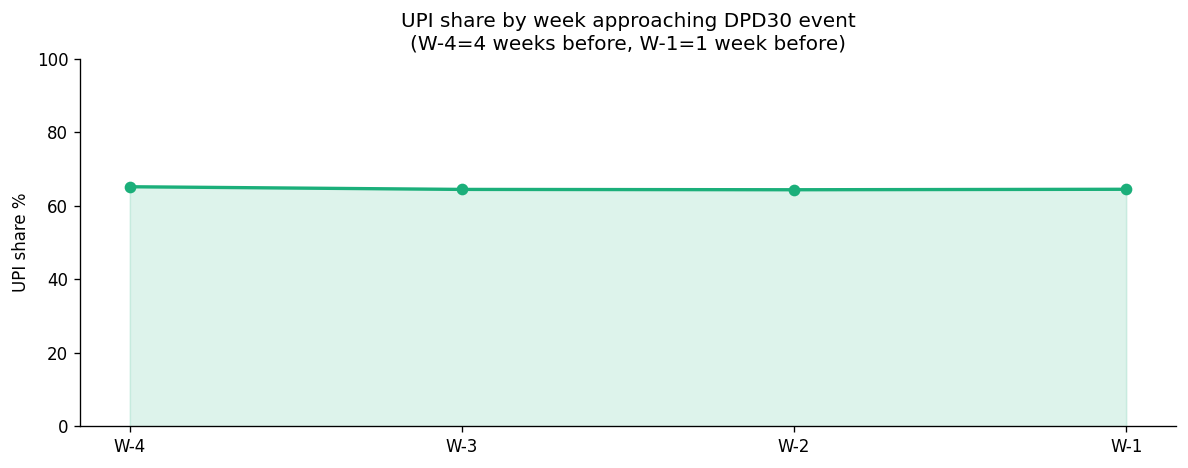

In [59]:
fig,ax=plt.subplots(figsize=(10,4))
ax.plot(upi_by_week.index.astype(str), upi_by_week.values, color="#1baf7a", marker="o", linewidth=2)
ax.fill_between(range(len(upi_by_week)), upi_by_week.values, alpha=0.15, color="#1baf7a")
ax.set_title("UPI share by week approaching DPD30 event\n(W-4=4 weeks before, W-1=1 week before)")
ax.set_ylim(0,100); ax.set_ylabel("UPI share %")
plt.tight_layout()
plt.savefig("../eda_outputs/q11_upi.png",dpi=150,bbox_inches="tight")
plt.show()

#### Finding: 
    UPI share remains flat at ~65% across W-4 to W-1 approaching the DPD30 event. 
    No decline signal detected

#### Q12: Are there loans with zero EMI payments recorded?

In [60]:
# Total paid_amount per loan
total_paid = (
    repayments.groupby("loan_id")["paid_amount"]
    .sum()
    .reset_index()
    .rename(columns={"paid_amount":"total_paid"})
)
zero_pay = total_paid[total_paid["total_paid"] == 0]
print(f"Loans with zero total paid: {len(zero_pay):,}")

Loans with zero total paid: 0


In [61]:
# Near-zero: paid less than one full EMI across entire tenure
avg_emi = repayments.groupby("loan_id")["emi_amount"].mean()
total_with_emi = total_paid.merge(avg_emi.rename("avg_emi"), on="loan_id")
near_zero = total_with_emi[total_with_emi["total_paid"] < total_with_emi["avg_emi"]]
print(f"Loans paid less than 1 EMI total: {len(near_zero):,}")

Loans paid less than 1 EMI total: 0


In [62]:
if len(near_zero) > 0:
    nz_merged = near_zero.merge(
        loans[["loan_id","credit_score_band","acquisition_channel"]], on="loan_id")
    print("\nAcquisition channel breakdown:")
    print(nz_merged["acquisition_channel"].value_counts())

#### Finding: 
    No loans with zero total EMI payments

#### Q13: Are there customers with 5+ loans — potential BNPL stacking fraud?

In [64]:
loan_counts=(
    loans.groupby("customer_id")["loan_id"].count()
    .reset_index().rename(columns={"loan_id":"loan_count"})
)

dist=loan_counts["loan_count"].value_counts().sort_index()
print("Loan count per customer:"); print(dist)
stackers=loan_counts[loan_counts["loan_count"]>=5]
print(f"\n5+ loan customers: {len(stackers):,} ({len(stackers)/len(loan_counts)*100:.2f}%)")

Loan count per customer:
loan_count
1    10659
2     6922
3     3156
4     1061
5      253
6       66
7       13
8        3
9        1
Name: count, dtype: int64

5+ loan customers: 336 (1.52%)


In [65]:
if len(stackers)>0:
    stacker_loans=loans[loans["customer_id"].isin(stackers["customer_id"])]
    print(f"Stacker NPA: {stacker_loans['is_defaulted'].mean()*100:.2f}% vs portfolio {loans['is_defaulted'].mean()*100:.2f}%")
    print(stacker_loans["acquisition_channel"].value_counts())

Stacker NPA: 37.14% vs portfolio 38.16%
acquisition_channel
organic      561
DSA          446
referral     348
affiliate    248
app_store    182
Name: count, dtype: int64


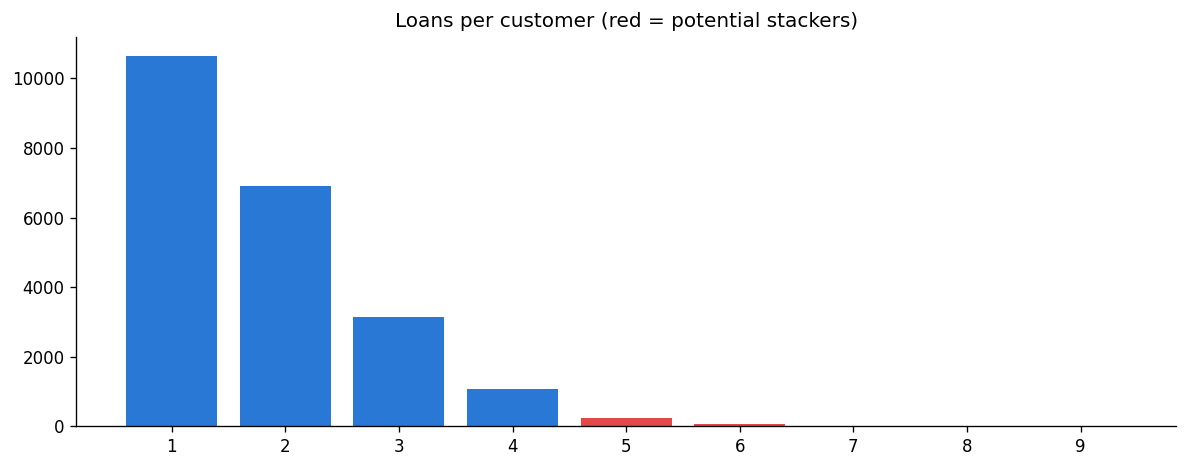

In [66]:
fig,ax=plt.subplots(figsize=(10,4))
ax.bar(dist.index.astype(str), dist.values,
       color=["#e34948" if v>=5 else "#2a78d6" for v in dist.index])
ax.set_title("Loans per customer (red = potential stackers)")
plt.tight_layout()
plt.savefig("../eda_outputs/q13_stacking.png",dpi=150,bbox_inches="tight")
plt.show()

#### Finding: 
       336 customers (1.52%) hold 5+ loans. 
       Stacker NPA: 37.14% vs portfolio 38.16% — a 1.02pp difference. 
       No elevated default risk detected for stackers.  
       Flag these customer IDs for manual review and exclude them from standard underwriting benchmarks.

In [68]:
transactions.head()

,txn_id,customer_id,txn_date,txn_amount,txn_type,merchant_category,txn_channel,city,is_declined,city_tier
0,TXN000000001,CUST0024356,2024-01-12,"2,693.42",credit,dining,UPI,Indore,0,tier2
1,TXN000000002,CUST0018507,2026-04-19,909.76,debit,travel,UPI,Ahmedabad,0,tier2
2,TXN000000003,CUST0017573,2024-09-21,163.28,debit,education,UPI,Indore,0,tier2
3,TXN000000004,CUST0004247,2025-03-19,"1,680.19",debit,dining,UPI,Surat,0,tier2
4,TXN000000005,CUST0005688,2027-01-31,253.62,credit,electronics,card,Chennai,0,tier1


In [71]:
repayments.head()
repayments.drop(columns=['disbursal_date_x','disbursal_date_y'], inplace=True)

In [69]:
loans.head()

,loan_id,customer_id,loan_amount,tenure_months,interest_rate,disbursal_date,city,income_band,credit_score_band,acquisition_channel,is_defaulted
0,LN00000001,CUST0013536,"1,862,622.24",18,10.54,2024-02-28,Delhi,>15L,650-850,referral,0
1,LN00000002,CUST0028028,"2,018,131.97",12,18.74,2025-02-08,Pune,>15L,600-650,DSA,0
2,LN00000003,CUST0019977,"1,422,386.90",18,14.21,2024-09-23,Kolkata,10-15L,650-850,organic,0
3,LN00000004,CUST0017979,"448,660.49",24,22.25,2025-05-09,Mumbai,6-10L,550-600,organic,1
4,LN00000005,CUST0028977,"112,484.70",24,15.27,2025-03-25,Pune,3-6L,650-850,organic,0


In [72]:
# Exporting the df as CSV

loans.to_csv("../data/processed/loans_processed.csv", index=False)
repayments.to_csv("../data/processed/repayments_processed.csv", index=False)
transactions.to_csv("../data/processed/transactions_processed.csv", index=False)

In [73]:
repayments.to_csv("../data/processed/repayments_processed(1).csv.gz", compression='gzip', index=False)